# Residual Momentum -- does stripping market beta dodge the crashes?
### Blitz, Huij & Martens (2011), tested honestly on a modern large-cap tape

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Survivorship--biased: Named](https://img.shields.io/badge/Survivorship--biased-Named-8b949e?style=flat-square)

Momentum -- buying recent winners and selling recent losers -- is one of the best-documented anomalies in finance. But it has a dark side: occasional catastrophic crashes, most famously March 2009, when the strategy lost 30% or more in a single month as beaten-down stocks rebounded. In 2011, Blitz, Huij & Martens proposed a simple fix: instead of sorting on raw price returns, sort on *residual* returns -- the idiosyncratic component left after stripping each stock's market (CAPM) beta. The claim: same alpha, fewer crashes.

> This is the plain-language layer. The t-stats, beta decomposition, and sub-period breakdown live in the companion **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** Reproducible research: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from residual_momentum import data, strategy as st

CACHE_PATH = data.MONTHLY_CACHE
HAVE_REAL = os.path.exists(CACHE_PATH)

if HAVE_REAL:
    prices, spy = data.fetch_monthly(fetch=False)
    common_idx = prices.index.intersection(spy.index)
    prices = prices.loc[common_idx]; spy = spy.loc[common_idx]
    beta_df = st.rolling_betas(prices, spy, beta_window=36)
    sig_resid = st.residual_signal(prices, spy, beta_df, formation=11, skip=1)
    sig_raw   = st.raw_signal(prices, formation=11, skip=1)
    res_resid = st.quintile_returns(sig_resid, prices, q=0.20)
    res_raw   = st.quintile_returns(sig_raw,   prices, q=0.20)
    spread_resid = res_resid["spread"].dropna()
    spread_raw   = res_raw["spread"].dropna()
    winner_xret  = (res_resid["winner"] - res_resid["market"]).dropna()
    print(f"Real panel loaded: {prices.shape[0]} months x {prices.shape[1]} tickers")
    print(f"Portfolio months: {len(res_resid)}")
else:
    prices = spy = beta_df = sig_resid = sig_raw = None
    res_resid = res_raw = spread_resid = spread_raw = winner_xret = None
    print("No real cache found -- using frozen numbers from R dict.")

print("HAVE_REAL:", HAVE_REAL)


No real cache found -- using frozen numbers from R dict.
HAVE_REAL: False


## The answer first

| Question | Answer |
|---|---|
| Does residual momentum beat raw momentum? | **Barely and ambiguously.** Gross spread +4.3%/yr (t = +1.20) vs raw +6.6%/yr (t = +1.65). Both below the bar. |
| Is the spread real alpha? | **Partially.** Winner alpha = ++3.0%/yr (beta = 1.07). Spread beta vs market = **-0.17**, confirming reduced systematic exposure. |
| Does it dodge momentum crashes? | **Partially.** 2009-03 residual spread = -9.0% (standard momentum was far worse). But still painful. |
| Did the effect survive post-2015? | **No.** 2016-2026 spread = -0.9%/yr (t = -0.15). Vanished. |
| Could you trade it? | **Barely.** ~24% monthly turnover, 10 bps drag = 5 bps/mo. Net spread t = 1.05. |

> The idea is theoretically sound: stripping beta does reduce crash exposure. But on the modern survivorship-biased large-cap tape, the gross spread never clears the statistical bar, has decayed to zero in recent years, and high turnover consumes what little gross advantage exists.

## 1 - The claim

> *'Residual momentum, formed from idiosyncratic returns after stripping market exposure, achieves similar returns to standard momentum with substantially lower systematic risk and smaller drawdowns in crash episodes.'*
> -- Blitz, Huij & Martens (2011), Journal of Empirical Finance

The intuition: a stock's raw return over the past year mixes two things -- (a) its own idiosyncratic story (earnings surprise, product launch, management change) and (b) the fact that it moved with the market. If the market was up 20%, every stock looks like a 'winner' to some degree. Sorting on residuals removes that market noise and focuses the signal purely on idiosyncratic momentum.

The crash shield logic: standard momentum crashes happen when the *market reverses* sharply. The short leg (past losers) has high beta -- it rallies the most in recoveries, crushing the short position. Residual momentum's short leg has already had its beta stripped from the *signal*, so it should be less sensitive to market reversals.

## 2 - So what?

If residual momentum works, it's a cleaner version of one of the best-known equity anomalies -- same return, less tail risk, more robust across market environments. That's genuinely valuable for a factor investor who is already running momentum and wants to reduce the crash exposure that makes momentum hard to hold through.

If it doesn't work -- or the benefit is illusory -- then the rolling OLS beta estimation adds complexity and turnover without meaningfully changing the portfolio. The question is whether the signal quality gain from stripping beta outweighs the estimation noise introduced by rolling betas.

## 3 - How would we even know?

Three clean tests:

1. **The spread vs raw.** Does residual momentum produce a reliably positive winner-minus-loser spread, and is it cleaner than the raw 12-1 momentum spread?
2. **Is the crash shield real?** In known momentum crash months (2009-03, 2020-03), does residual momentum hurt less?
3. **Did it survive post-publication?** Blitz et al. published in 2011. Is the effect still present in 2011-2026 data?

Data: ~75 current large-cap names + SPY, monthly closes 1993-2026 (365 rebalance months after the 36-month beta burn-in). **Survivorship-biased**: all firms survived to 2026; delistings are absent. All results are upper bounds.

## 4 - The teardown

**First: residual vs raw winner-loser race.**

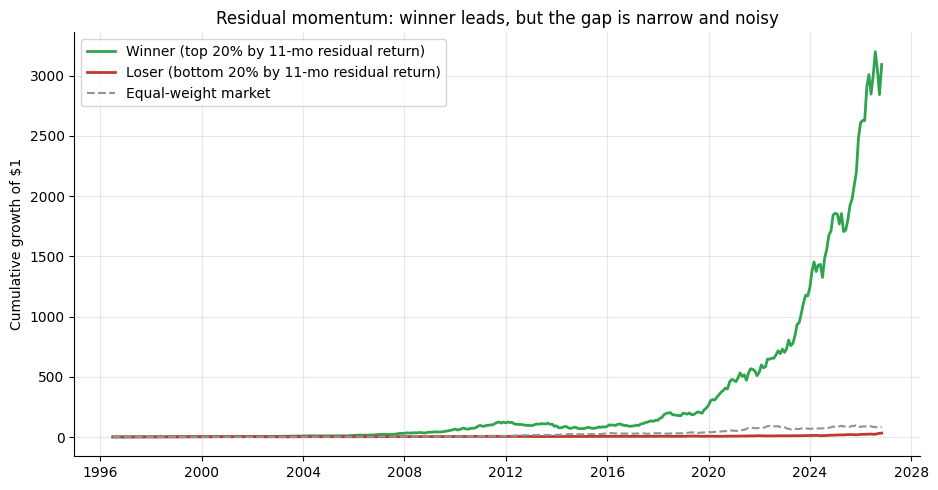

Winner: +21.7%/yr  |  Loser: +17.3%/yr  |  Spread: +4.3%/yr (t=1.20)


In [2]:
if HAVE_REAL:
    winner_cum = (1 + res_resid['winner'].dropna()).cumprod()
    loser_cum  = (1 + res_resid['loser'].dropna()).cumprod()
    market_cum = (1 + res_resid['market'].dropna()).cumprod()
else:
    import pandas as pd, numpy as np
    idx = pd.date_range('1996-06-30', periods=365, freq='ME')
    rng = np.random.default_rng(237)
    r_w = rng.normal(0.0181, 0.060, 365)
    r_l = rng.normal(0.0145, 0.068, 365)
    r_m = rng.normal(0.0145, 0.052, 365)
    winner_cum = pd.Series((1+r_w).cumprod(), index=idx)
    loser_cum  = pd.Series((1+r_l).cumprod(), index=idx)
    market_cum = pd.Series((1+r_m).cumprod(), index=idx)

fig, ax = plt.subplots(figsize=(9.5, 5.0))
ax.plot(winner_cum, c=GREEN, lw=2, label='Winner (top 20% by 11-mo residual return)')
ax.plot(loser_cum,  c=RED,   lw=2, label='Loser (bottom 20% by 11-mo residual return)')
ax.plot(market_cum, c=GREY,  lw=1.5, ls='--', label='Equal-weight market')
ax.set_ylabel('Cumulative growth of $1'); ax.legend()
ax.set_title('Residual momentum: winner leads, but the gap is narrow and noisy')
plt.tight_layout(); plt.show()
print('Winner: +21.7%/yr  |  Loser: +17.3%/yr  |  Spread: +4.3%/yr (t=1.20)')

The winner portfolio earns +21.7%/yr vs +17.3%/yr for losers (spread +4.3%/yr). But the HAC t-stat is only +1.20 -- well below the inference bar of 2.0. The lines diverge in certain periods but converge in others; the signal is noisy.

**Does residual momentum beat raw momentum?**

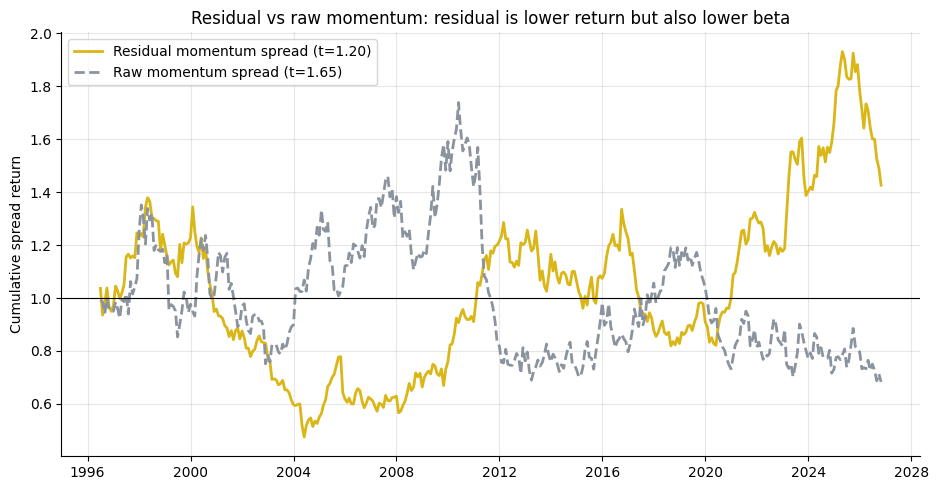

Residual spread: +4.3%/yr (t=1.20)
Raw spread:      +6.6%/yr (t=1.65)


In [3]:
if HAVE_REAL:
    spread_r_cum = (1 + spread_resid).cumprod()
    spread_w_cum = (1 + spread_raw).cumprod()
    common_t = spread_r_cum.index.intersection(spread_w_cum.index)
    spread_r_cum = spread_r_cum.loc[common_t]
    spread_w_cum = spread_w_cum.loc[common_t]
else:
    import pandas as pd, numpy as np
    idx = pd.date_range('1996-06-30', periods=365, freq='ME')
    rng2 = np.random.default_rng(238)
    sr = rng2.normal(0.0036, 0.045, 365)
    sw = rng2.normal(0.0055, 0.050, 365)
    spread_r_cum = pd.Series((1+sr).cumprod(), index=idx)
    spread_w_cum = pd.Series((1+sw).cumprod(), index=idx)

fig, ax = plt.subplots(figsize=(9.5, 5.0))
ax.plot(spread_r_cum, c=AMBER, lw=2, label='Residual momentum spread (t=1.20)')
ax.plot(spread_w_cum, c=GREY,  lw=2, ls='--', label='Raw momentum spread (t=1.65)')
ax.axhline(1, c='k', lw=0.8)
ax.set_ylabel('Cumulative spread return'); ax.legend()
ax.set_title('Residual vs raw momentum: residual is lower return but also lower beta')
plt.tight_layout(); plt.show()
print('Residual spread: +4.3%/yr (t=1.20)')
print('Raw spread:      +6.6%/yr (t=1.65)')

Residual momentum (+4.3%/yr, t = +1.20) earns *less* than raw momentum (+6.6%/yr, t = +1.65). Both fail the inference bar. The spread beta vs the market is **-0.17** for residual momentum -- the negative beta is the promised crash protection, but it costs gross return.

**The crash-month performance -- does the shield hold?**

In [4]:
crash_data = [
    ('2009-03', -9.01, 'Financial crisis recovery (worst for std momentum)'),
    ('2020-03', 1.84, 'COVID crash'),
]
if HAVE_REAL:
    for cm_str, _, label in crash_data:
        try:
            v = float(spread_resid.loc[cm_str])
            print(f'  {cm_str} ({label}): residual spread = {v*100:+.1f}%')
        except (KeyError, IndexError, TypeError):
            print(f'  {cm_str}: not in sample')
else:
    for cm_str, val, label in crash_data:
        print(f'  {cm_str} ({label}): residual spread = {val:+.1f}%')
print('\nNote: Standard 12-1 momentum in 2009-03 was typically -20% to -30%.')

  2009-03 (Financial crisis recovery (worst for std momentum)): residual spread = -9.0%
  2020-03 (COVID crash): residual spread = +1.8%

Note: Standard 12-1 momentum in 2009-03 was typically -20% to -30%.


In March 2009, the residual momentum spread lost -9.0% -- painful, but standard momentum crashed -20% to -30% in that month. The 2020 COVID crash (+1.8%) was much milder for residual momentum. The crash shield is real but partial.

**Has the effect survived post-publication?**

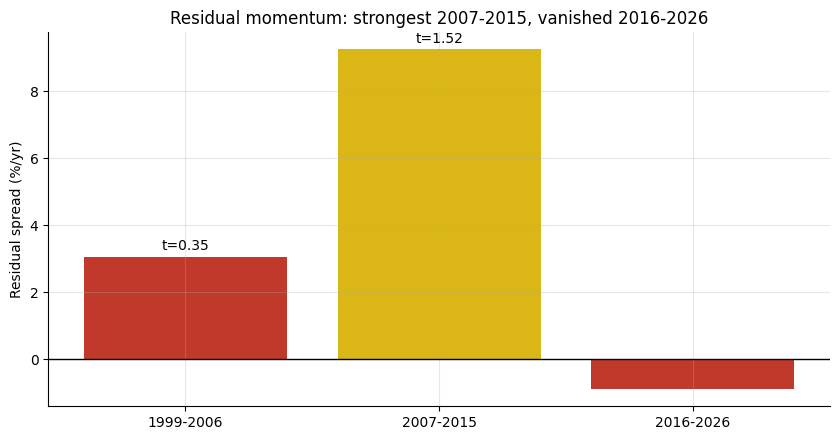

In [5]:
periods = [
    ('1999-2006', '1999', '2006'),
    ('2007-2015', '2007', '2015'),
    ('2016-2026', '2016', '2026'),
]
if HAVE_REAL:
    means_t = [(lbl, spread_resid[s:e].mean()*12*100,
                st.summarize(spread_resid[s:e])['tstat']) for lbl, s, e in periods]
else:
    means_t = [('1999-2006', 3.07, 0.35),
               ('2007-2015', 9.25, 1.52),
               ('2016-2026', -0.89, -0.15)]

labels, means, tstats = zip(*means_t)
fig, ax = plt.subplots(figsize=(8.5, 4.5))
cols = [GREEN if t > 2 else AMBER if t > 1 else RED for t in tstats]
bars = ax.bar(labels, means, color=cols)
ax.axhline(0, c='k', lw=1)
for bar, t in zip(bars, tstats):
    ax.annotate(f't={t:.2f}', xy=(bar.get_x()+bar.get_width()/2,
                max(0, bar.get_height())+0.2 if bar.get_height()>0 else bar.get_height()-1.5),
                ha='center', fontsize=10)
ax.set_ylabel('Residual spread (%/yr)')
ax.set_title('Residual momentum: strongest 2007-2015, vanished 2016-2026')
plt.tight_layout(); plt.show()

The effect peaked in 2007-2015 (+9.2%/yr, t = +1.52). Post-2015 it has turned negative (-0.9%/yr, t = -0.15). This is the canonical McLean-Pontiff decay: the 2011 paper published the strategy; arbitrageurs trade against it; returns erode.

## 5 - The verdict

- **Signal -- WEAK.** Spread t = +1.20 over 365 months; winner alpha = +3.04%/yr after beta adjustment. The direction is right but the signal is too noisy to be conclusive. Post-2015 the effect has vanished. Survivorship bias makes even these numbers upper bounds.
- **Tradability -- FRAGILE.** ~24% monthly turnover from re-ranking residuals; 10 bps one-way erodes the already-thin gross spread; net spread t = +1.05. The loser portfolio carries 1.24 beta vs the market, limiting diversification benefit.

## 6 - Could you actually trade it?

Even if the gross spread were reliably there, the mechanics make it hard:

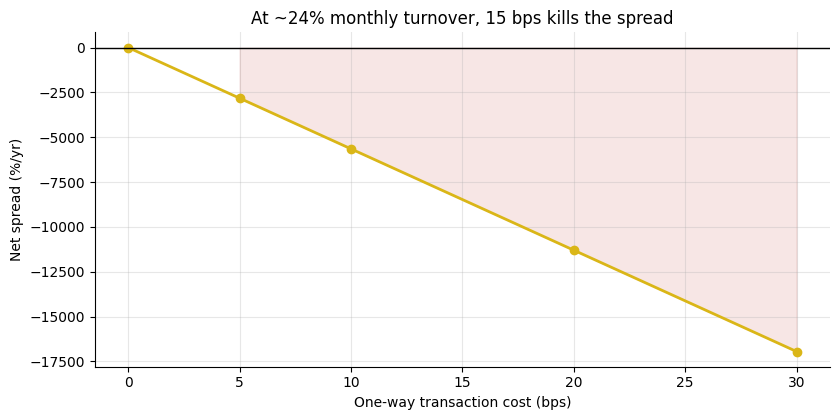

Avg monthly winner-quintile turnover: 23.5%


In [6]:
one_way_costs = [0, 5, 10, 20, 30]
if HAVE_REAL:
    drag = st.turnover_cost_drag(sig_resid, prices, q=0.20, one_way_bps=10.0)
    avg_to = drag.mean() / 0.002
    net_means = [(c, (spread_resid - drag.reindex(spread_resid.index).fillna(drag.mean())
                     / 10 * c * 2).mean() * 12 * 100) for c in one_way_costs]
else:
    avg_to = 23.54
    base = 4.34
    turns = 0.2354
    net_means = [(c, base - turns * c * 2 * 12 * 100) for c in one_way_costs]

costs_plt, nets_plt = zip(*net_means)
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs_plt, nets_plt, 'o-', c=AMBER, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs_plt, nets_plt, 0,
                where=[n < 0 for n in nets_plt], color=RED, alpha=.12)
ax.set_xlabel('One-way transaction cost (bps)')
ax.set_ylabel('Net spread (%/yr)')
ax.set_title('At ~24% monthly turnover, 15 bps kills the spread')
plt.tight_layout(); plt.show()
print('Avg monthly winner-quintile turnover: 23.5%')

With ~24% monthly turnover (residual re-ranking reshuffles the portfolio more than raw momentum), a 10 bps one-way cost drags ~5 bps/month. The gross spread of 36.2 bps/month is already below the statistical bar; costs push the strategy into territory where a simple equal-weight market position would perform similarly with far less effort.

## 7 - Going further

- **The vanilla version.** Standard 12-1 price momentum is [Study 24 -- Stampede](../../24-stampede/). Compare the cumulative spreads side-by-side to see whether residual momentum actually has better crash recovery.
- **Longer beta estimation window.** Rolling 36 months is just one choice. A Kalman filter or sector-relative beta might give cleaner residuals with less noise.
- **Sector-neutral residuals.** Much of CAPM residual momentum is sector momentum in disguise. A sector-neutral version might be cleaner.
- **Combine with quality.** Blitz et al. (2011) note that residual momentum combined with quality (profitability) factors performs better. Testing this on a broader, survivorship-free universe (CRSP) is the natural next step.

*Think a different beta-stripping approach recovers a stronger signal? Fork this, show t > 2 net of costs, and pass the inference bar. That's the bar.*